
Gravity Details

Acceleration of gravity at surface level:    9.7913 m/s²
Acceleration of gravity at  13.933 km (ASL): 9.7512 m/s²


Launch Site Details

Launch Date: 2025-02-03 12:00:00 UTC
Launch Site Latitude: 31.03012°
Launch Site Longitude: -103.32505°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 87049.34 W    3440983.97 N
Launch Site UTM zone: 13R
Launch Site Surface Elevation: 881.0 m


Atmospheric Model Details

Atmospheric Model Type: Windy
Windy Maximum Height: 13.933 km

Surface Atmospheric Conditions

Surface Wind Speed: 7.63 m/s
Surface Wind Direction: 253.47°
Surface Wind Heading: 73.47°
Surface Pressure: 912.91 hPa
Surface Temperature: 290.71 K
Surface Air Density: 1.094 kg/m³
Surface Speed of Sound: 341.80 m/s


Earth Model Details

Earth Radius at Launch site: 6372.49 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



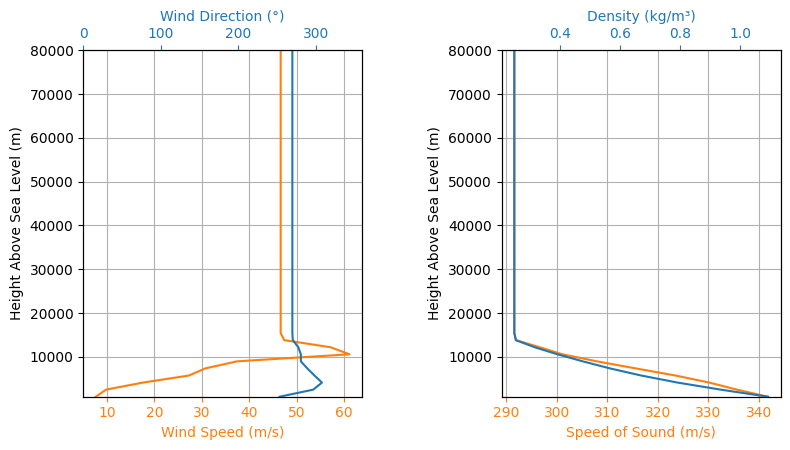

In [1]:
from rocketpy import Environment, SolidMotor, Rocket, Flight
env = Environment(latitude=31.03012, longitude=-103.32505, elevation=892)
import datetime

tomorrow = datetime.date.today() + datetime.timedelta(days=1)

env.set_date(
    (2025, 2, 3, 12)
)  # Hour given in UTC time

env.set_atmospheric_model(type="Windy", file="GFS")

env.info()

# PLEASE ENTER ITERATION: C5

Defining Motor (O500X-PS)

Nozzle Details
Nozzle Radius: 0.035 m
Nozzle Throat Radius: 0.016 m

Grain Details
Number of Grains: 7
Grain Spacing: 0.0015875 m
Grain Density: 1513.695547 kg/m3
Grain Outer Radius: 0.042799 m
Grain Inner Radius: 0.01905 m
Grain Height: 0.2 m
Grain Volume: 0.001 m3
Grain Mass: 1.397 kg

Motor Details
Total Burning Time: 3.86 s
Total Propellant Mass: 9.779 kg
Average Propellant Exhaust Velocity: 2185.164 m/s
Average Thrust: 5535.937 N
Maximum Thrust: 7724.49 N at 1.491 s after ignition.
Total Impulse: 21368.718 Ns



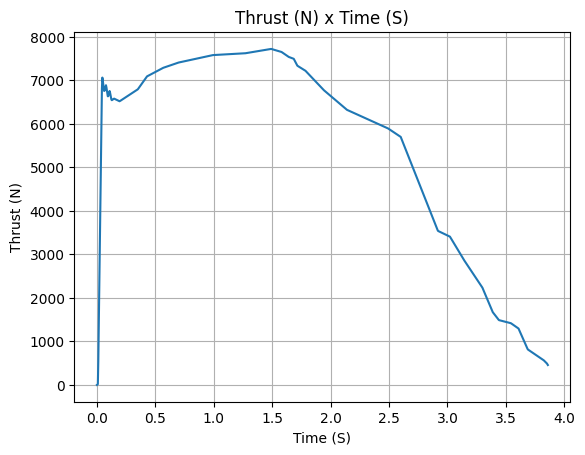

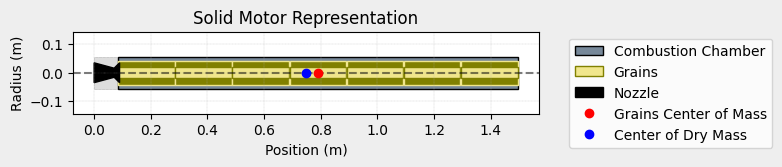

In [2]:
O5500 = SolidMotor(
    thrust_source=r"/Users/jom/Desktop/CUHAR/Flight_dynamic_2023/propulsion/AeroTech_O5500X-PS-actual.eng",
    dry_mass=7.004,
    dry_inertia=(1.33, 1.33, 0.0084),
    nozzle_radius=0.07 / 2,
    grain_number=7,
    grain_density=1513.695547,
    grain_outer_radius=0.042799,
    grain_initial_inner_radius=0.01905,
    grain_initial_height=0.2,
    grain_separation=0.0015875,
    grains_center_of_mass_position=0.79,
    center_of_dry_mass_position=0.7475,
    nozzle_position=0,
    burn_time=3.86,
    throat_radius=0.032 / 2,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

O5500.info()
O5500.plots.draw()

Defining the rocket

In [3]:
cursr_4 = Rocket(
    radius= 15.7 / 200,
    mass=17.431,
    inertia=(19.563, 19.563, 0.088), 
    #???? check pls cuz i add in motor to run the sim but in documentation they say it must be dry rocket inertia
    power_off_drag="/Users/jom/Desktop/CUHAR/2024/FlightDynamics/Data/Mach_Cd/C4_Mach_Cd_CFD.csv",
    power_on_drag="/Users/jom/Desktop/CUHAR/2024/FlightDynamics/Data/Mach_Cd/C4_Mach_Cd_CFD.csv",
    center_of_mass_without_motor=1.47,
    coordinate_system_orientation="nose_to_tail",
)

In [4]:
cursr_4.add_motor(O5500, position=3.17)

rail_buttons = cursr_4.set_rail_buttons(
    upper_button_position= 159 / 100,
    lower_button_position= 306 / 100,
    angular_position=45,
)

nose_cone = cursr_4.add_nose(
    length= 79.9 / 100, 
    kind="von karman", 
    position=0
)

fin_set = cursr_4.add_trapezoidal_fins(
    n=4,
    root_chord= 30 / 100,
    tip_chord= 10 / 100,
    span= 13 / 100,
    position= 275 / 100,
    cant_angle= 0,
    sweep_angle= 55,
    airfoil= None
)

transition = cursr_4.add_tail(
    top_radius= 15.7 / 200, 
    bottom_radius= 12.7 / 200, 
    length= 20 / 100, 
    position= (315 - 4.55 - 5.13 - 0.52 - 125 - 20) / 100
)

aft_boattail = cursr_4.add_tail(
    top_radius= 12.7 / 200, 
    bottom_radius= 12.5 / 200, 
    length= 5.13 / 100, 
    position= (315 - 4.55 - 5.13) / 100
)

fore_boattail = cursr_4.add_tail(
    top_radius= 12.5 / 200, 
    bottom_radius= 10 / 200, 
    length= 4.55 / 100, 
    position= (315 - 4.55) / 100
)

#specs for parachute, to be determined later. Rn use last year specifications.

main = cursr_4.add_parachute(
    name="Main",
    cd_s=2.2 * 3.14 * 1.22 * 1.22,
    trigger=400,
    sampling_rate=105,
    lag=0,
    noise=(0, 3, 0.5),
)

drogue = cursr_4.add_parachute(
    name="Drogue",
    cd_s=0.97 * 3.14 * 0.462 * 0.462,
    trigger="apogee",
    sampling_rate=105,
    lag=1,
    noise=(0, 3, 0.5),
)

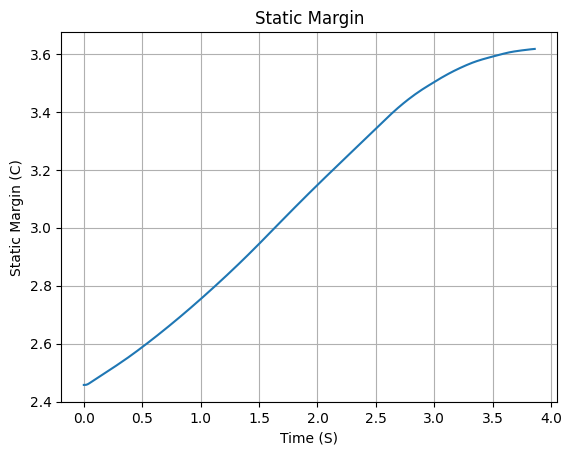

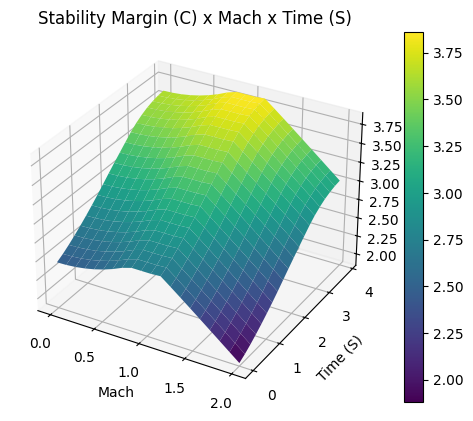

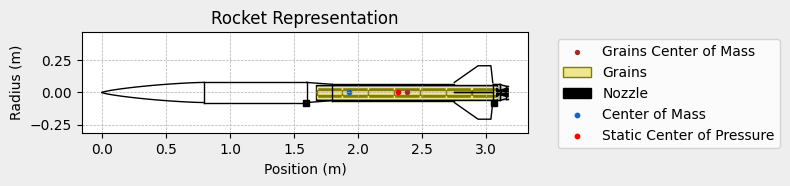

In [5]:
cursr_4.plots.static_margin()
cursr_4.plots.stability_margin()
cursr_4.draw()

Data:

Apogee (ft):                28784.43
Max Speed (ft/s):           1992.32
Max Acceleration (ft/s²):   797.80

Apogee (m):                 8773.49
Max Speed (m/s):            607.26
Max Acceleration (m/s²):    243.17

Max Mach Number:            1.80
Initial Stability Margin:   2.46
Out of Rail Stability:      2.51

Max Dynamic Pressure (Pa):  180832.29
Max Total Pressure (Pa):    458153.14

Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 881.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.859 | e1: 0.009 | e2: 0.034 | e3: -0.511
Euler Angles - Spin φ : -45.00° | Nutation θ: -4.00° | Precession ψ: -253.47°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.458 c


Surface Wind Conditions

Frontal Surface Wind Speed: -7.63 m/s
Lateral Surface Wind Speed: -0.00 m/s


Launch Rail

Launch Rail Length: 5.18 m
Launch Rail Inclination: 86.00°
Launch Rail Heading: 253.47

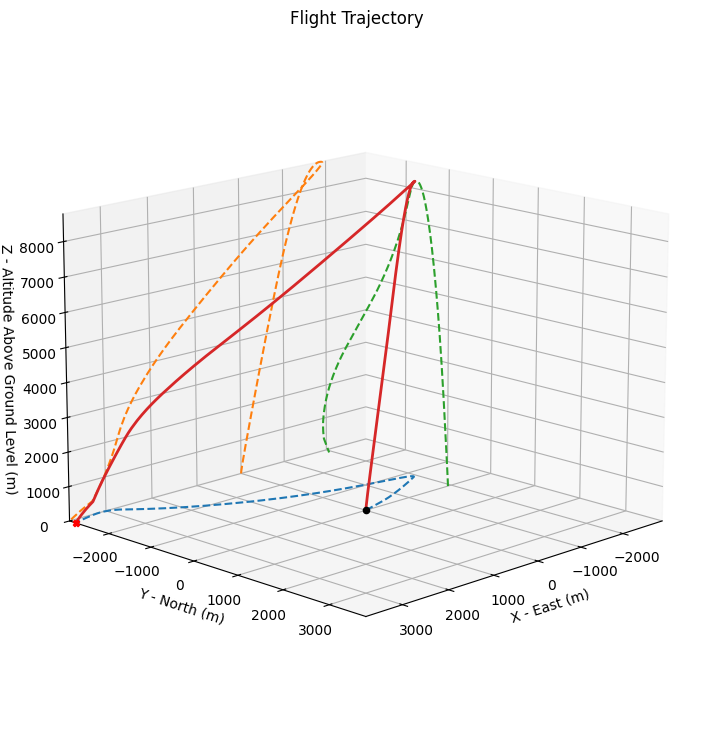



Trajectory Kinematic Plots



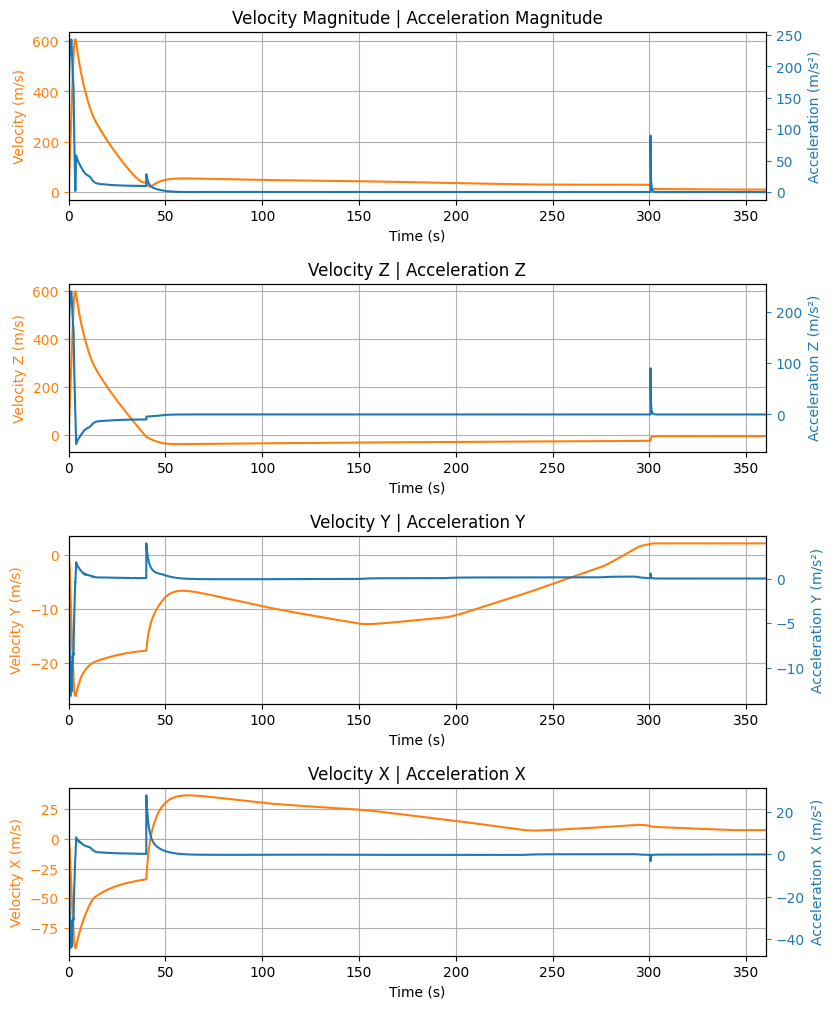



Angular Position Plots



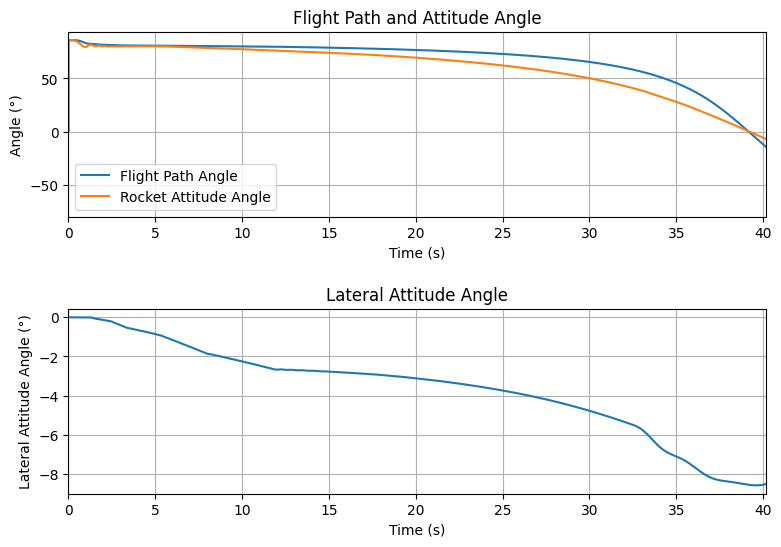



Path, Attitude and Lateral Attitude Angle plots



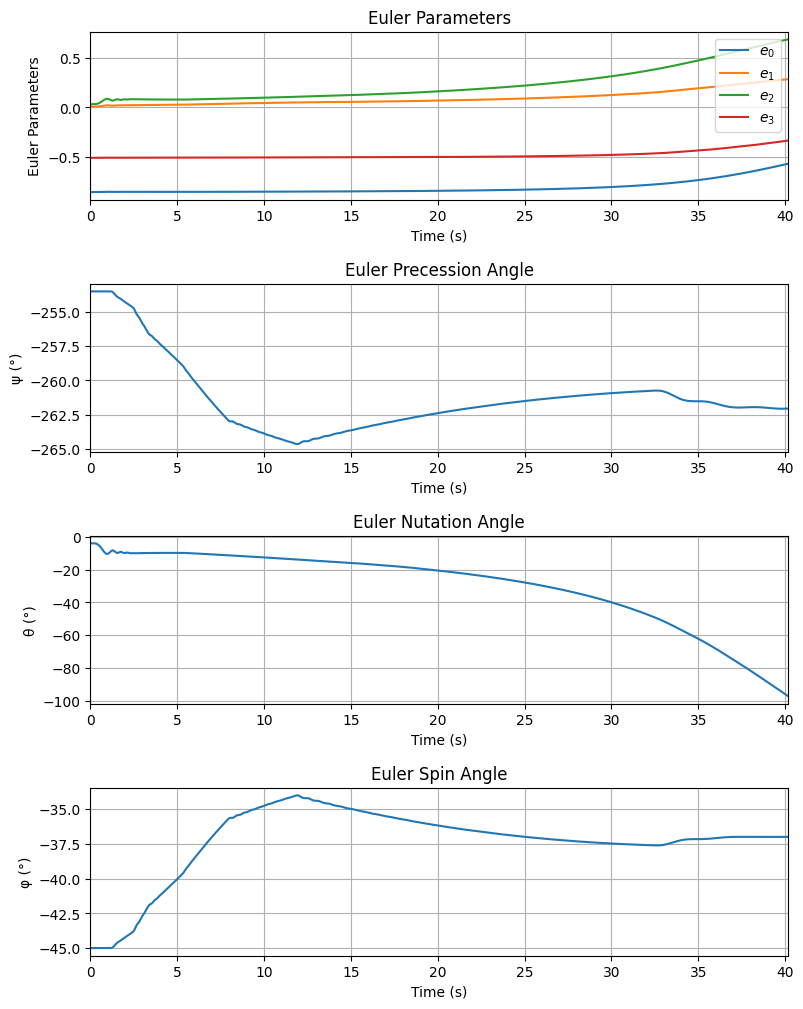



Trajectory Angular Velocity and Acceleration Plots



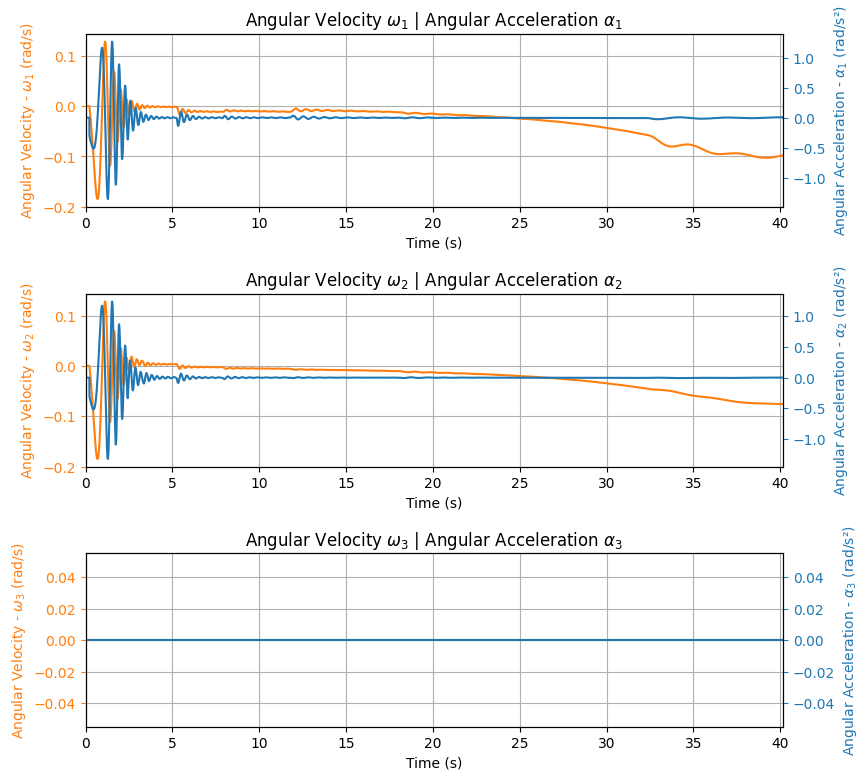



Aerodynamic Forces Plots



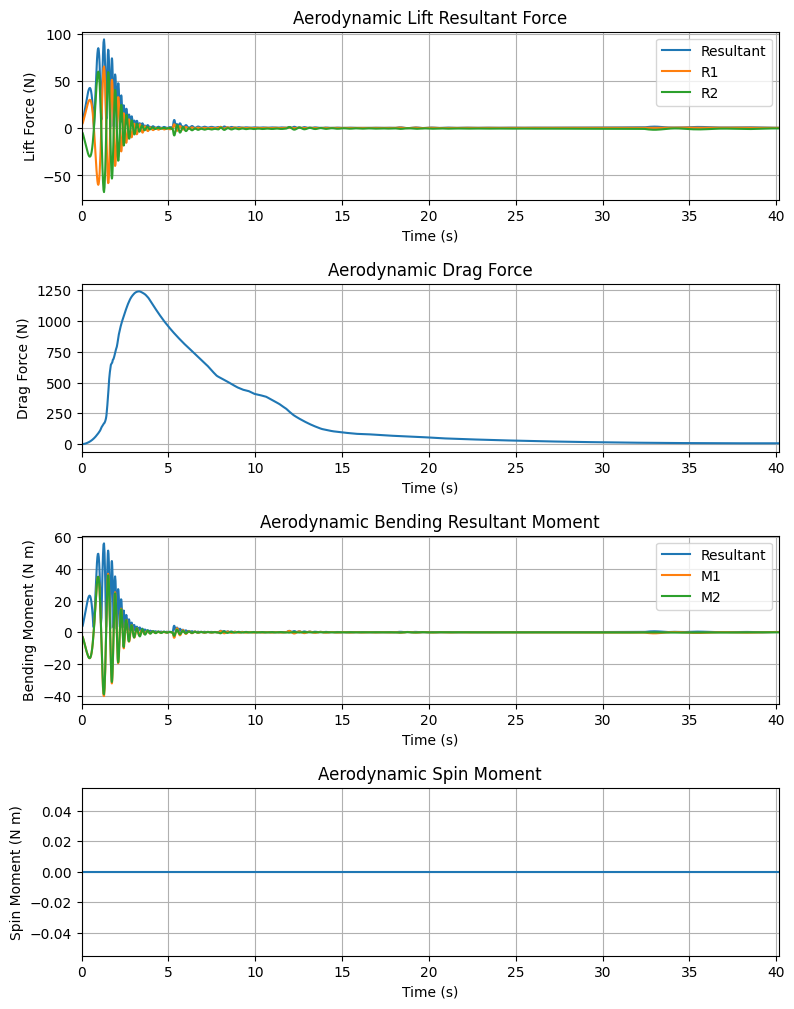



Rail Buttons Forces Plots



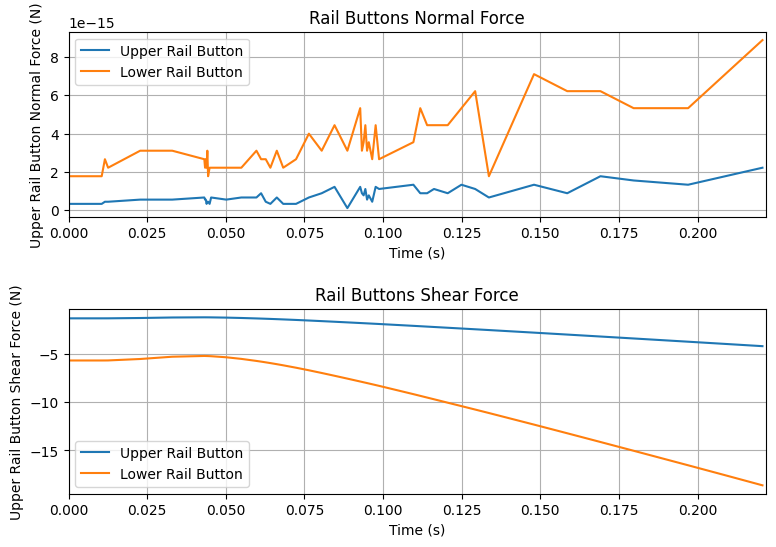



Trajectory Energy Plots



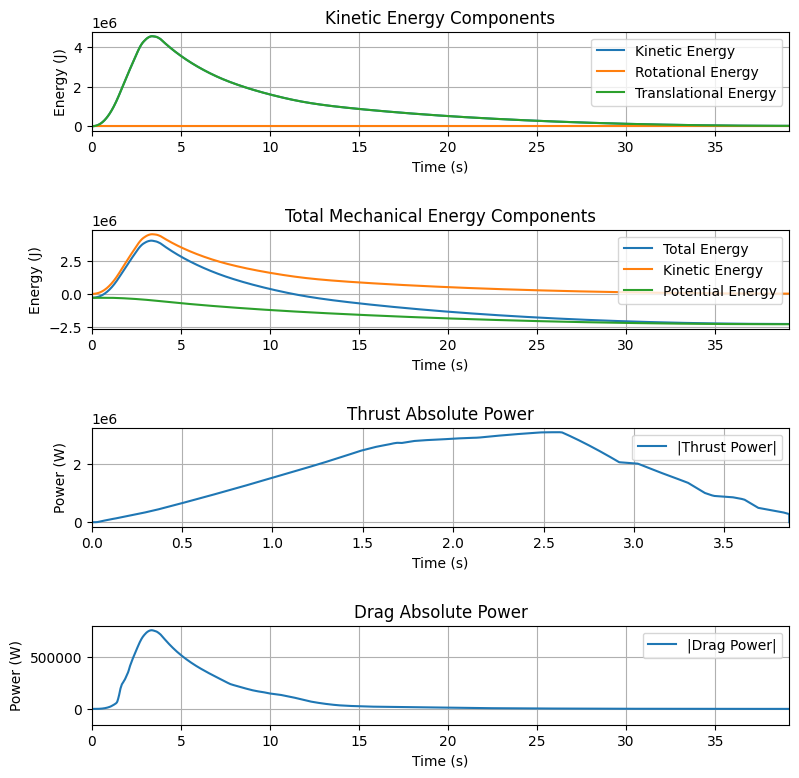



Trajectory Fluid Mechanics Plots



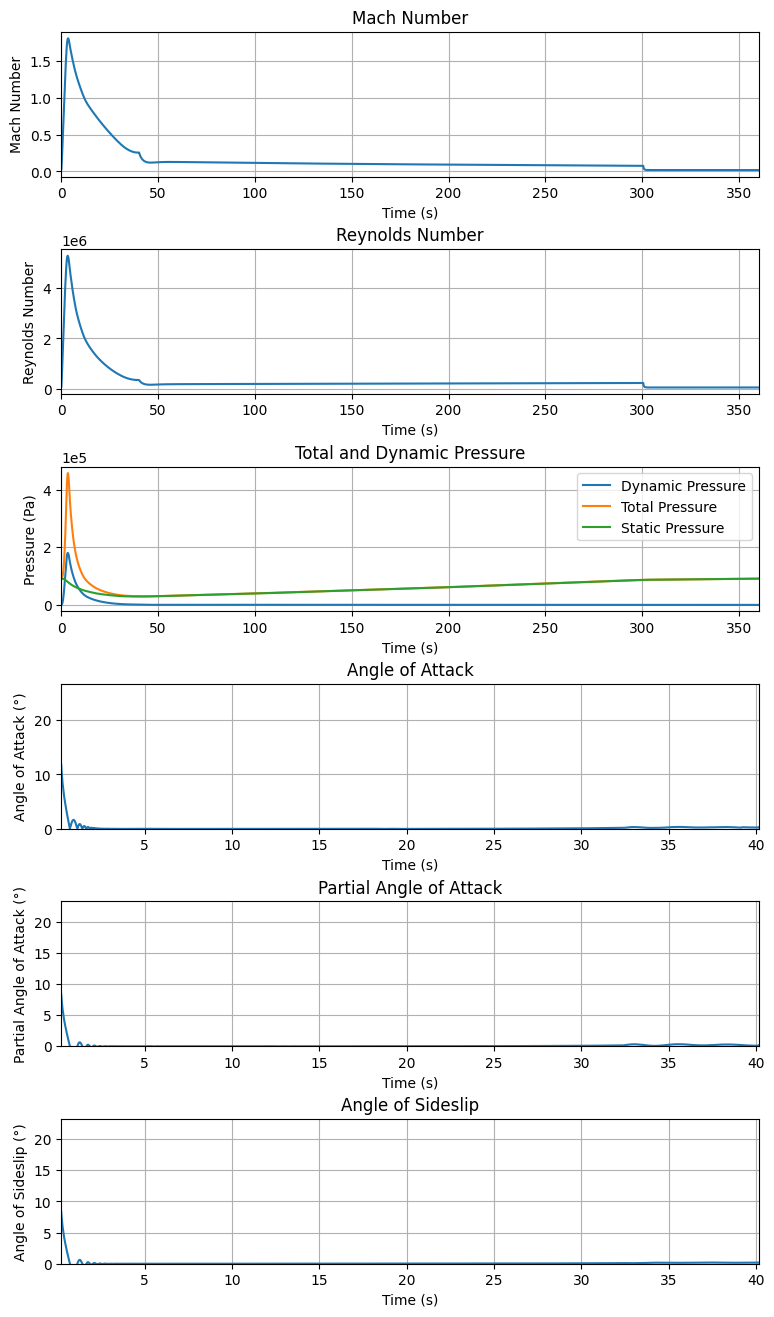



Trajectory Stability and Control Plots



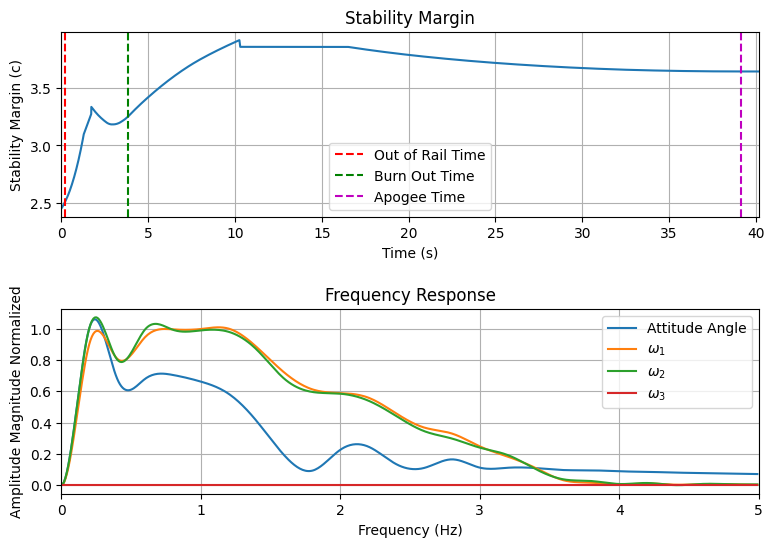



Rocket and Parachute Pressure Plots



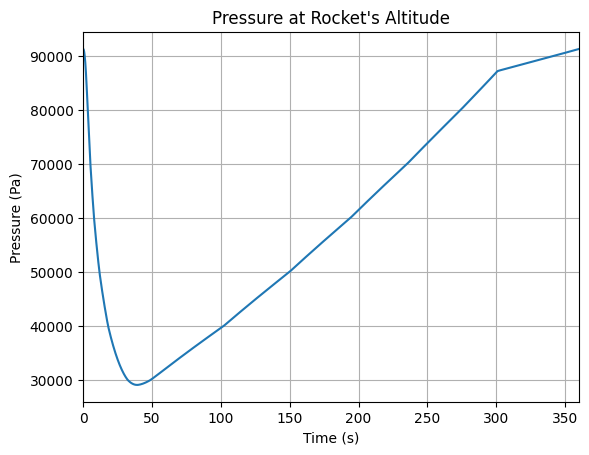


Parachute:  Main


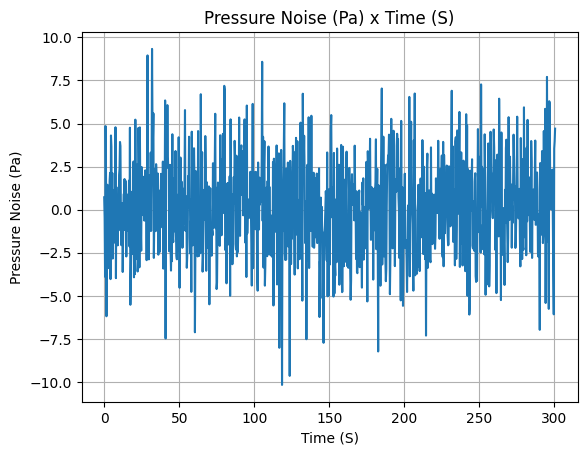

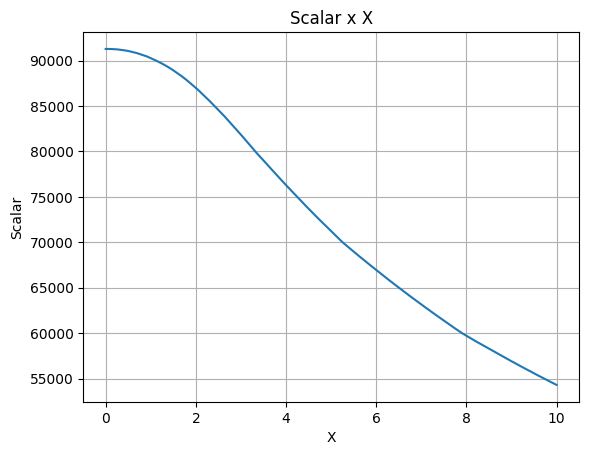

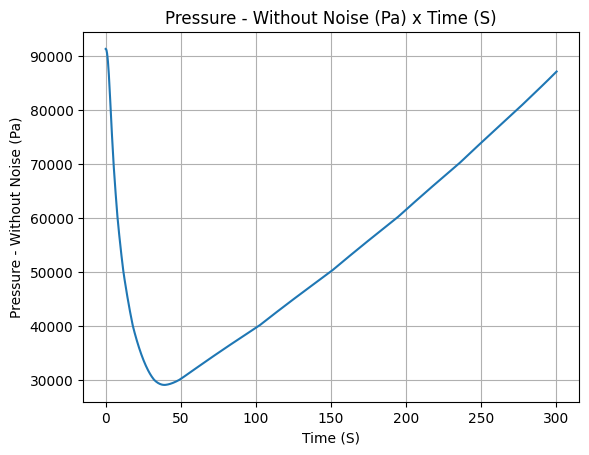


Parachute:  Drogue


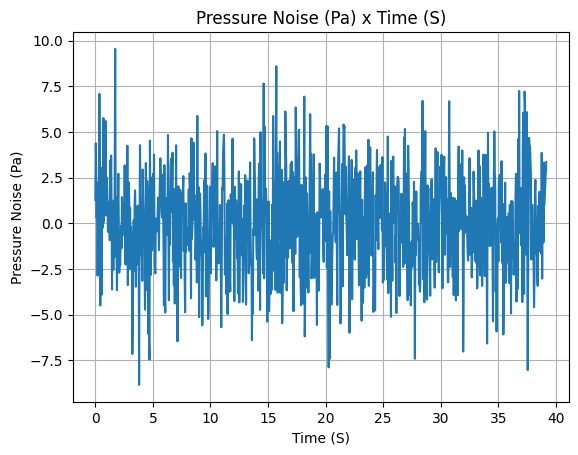

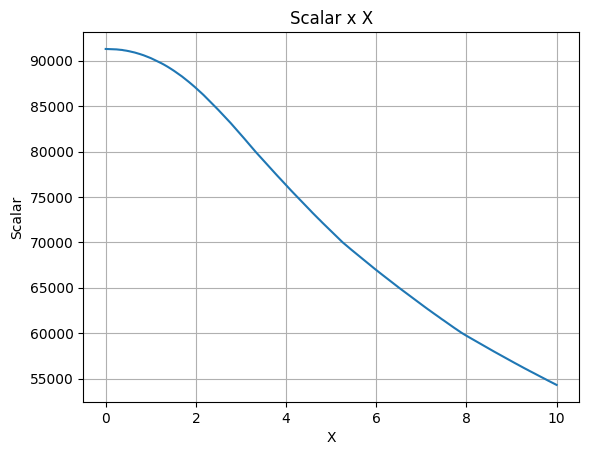

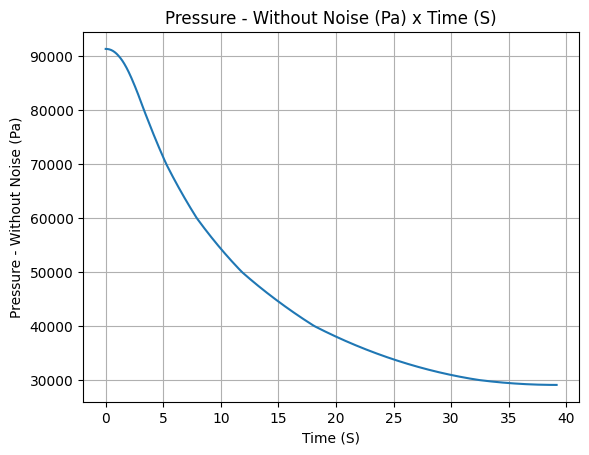

In [6]:
test_flight = Flight(
    rocket=cursr_4,
    environment=env,
    rail_length=5.18,
    inclination=86,
    heading=env.wind_direction(env.elevation),
    equations_of_motion="solid_propulsion"
)

M_TO_FT = 3.28084
M_TO_FT = 3.28084
M_S_TO_FT_S = 3.28084
M_S2_TO_FT_S2 = 3.28084 


print("Data:")
print()

print(f"Apogee (ft):                {(test_flight.apogee - env.elevation) * M_TO_FT:.2f}")
print(f"Max Speed (ft/s):           {test_flight.max_speed * M_S_TO_FT_S:.2f}")
print(f"Max Acceleration (ft/s²):   {test_flight.max_acceleration * M_S2_TO_FT_S2:.2f}")
print()

print(f"Apogee (m):                 {(test_flight.apogee - env.elevation):.2f}")
print(f"Max Speed (m/s):            {test_flight.max_speed:.2f}")
print(f"Max Acceleration (m/s²):    {test_flight.max_acceleration:.2f}")
print()

print(f"Max Mach Number:            {test_flight.max_mach_number:.2f}")
print(f"Initial Stability Margin:   {test_flight.initial_stability_margin:.2f}")
print(f"Out of Rail Stability:      {test_flight.out_of_rail_stability_margin:.2f}")
print()

print(f"Max Dynamic Pressure (Pa):  {test_flight.max_dynamic_pressure:.2f}")
print(f"Max Total Pressure (Pa):    {test_flight.max_total_pressure:.2f}")


test_flight.all_info()


